# Broadband resonator spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal02_resonator_spectroscopy_full_bandwidth import BroadbandResonatorSpectroscopy

## Run parameters

In [2]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config_upd.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # Use None if no flux bias needed
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
FREQUENCY_CENTER = 7.5e9
FREQUENCY_WIDTH = 1.6e9
FREQUENCY_POINTS = 1601
MAXIMUM_BRANCH_WIDTH = 800e6
REPETITIONS = 10

READOUT_AMPLITUDE = 0.08
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
RESTORE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_DETECTED_DEVICE = Path(r"..\config\dut_config_upd.json")  # Use None if param persisting is not required

## Hardware and experiment

In [3]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = BroadbandResonatorSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Optional: Print branch plan

In [4]:
branches = experiment.plan_branches(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
)
for branch in branches:
    print(
        f"Branch {branch.index + 1}: "
        f"{branch.start / 1e9:.6f}–{branch.stop / 1e9:.6f} GHz, "
        f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
        f"{branch.points} points"
    )

Branch 1: 6.700000–7.500000 GHz, LO 7.100000 GHz, 801 points
Branch 2: 7.501000–8.300000 GHz, LO 7.900500 GHz, 800 points


## Measurement

In [5]:
dataset = experiment.run_measurement(
        frequency_center=FREQUENCY_CENTER,
        frequency_width=FREQUENCY_WIDTH,
        frequency_points=FREQUENCY_POINTS,
        maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
        repetitions=REPETITIONS,
        readout_amplitude=READOUT_AMPLITUDE,
        output_attenuation=OUTPUT_ATTENUATION,
        input_attenuation=INPUT_ATTENUATION,
        restore_lo_frequency=RESTORE_LO_FREQUENCY,
        timeout=TIMEOUT,
    )
dataset

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 51kB
Dimensions:           (acq_index_S21_q0: 1601)
Coordinates:
    frequency_q0      (acq_index_S21_q0) float64 13kB 6.7e+09 ... 8.3e+09
  * acq_index_S21_q0  (acq_index_S21_q0) int64 13kB 0 1 2 3 ... 1598 1599 1600
Data variables:
    S21_q0            (acq_index_S21_q0) complex128 26kB (0.02278818392753601...
Attributes:
    tuid:     20260806-165710-981-8d919b

## Optional: Simulated data

In [6]:
dataset = experiment.simulated_data(
    frequency_center=7.5e9,
    frequency_width=40e6,
    frequency_points=401,
    resonance_frequency=7.495e9,
    loaded_quality_factor=8_000,
    coupling_quality_factor=12_000,
    signal_amplitude=1.0,
    noise=0.01,
    electrical_delay=20e-9,
    phase_offset=0.0,
    asymmetry=0.0,
    seed=42,
)
dataset

<xarray.Dataset> Size: 10kB
Dimensions:       (acq_index_S21_q0: 401)
Coordinates:
    frequency_q0  (acq_index_S21_q0) float64 3kB 7.48e+09 7.48e+09 ... 7.52e+09
Dimensions without coordinates: acq_index_S21_q0
Data variables:
    S21_q0        (acq_index_S21_q0) complex128 6kB (-0.7932188949188327+0.60...
Attributes:
    simulated:         True
    simulation_model:  qblox_scheduler.hanger_func_complex_SI

## Analysis

In [7]:
results = experiment.analysis()
for qubit, result in results.items():
    print(
        f"{qubit}: deepest dip at {result.frequency / 1e9:.9f} GHz, "
        f"|S21| = {result.magnitude:.6g}"
    )

q0: deepest dip at 7.495000000 GHz, |S21| = 0.335365


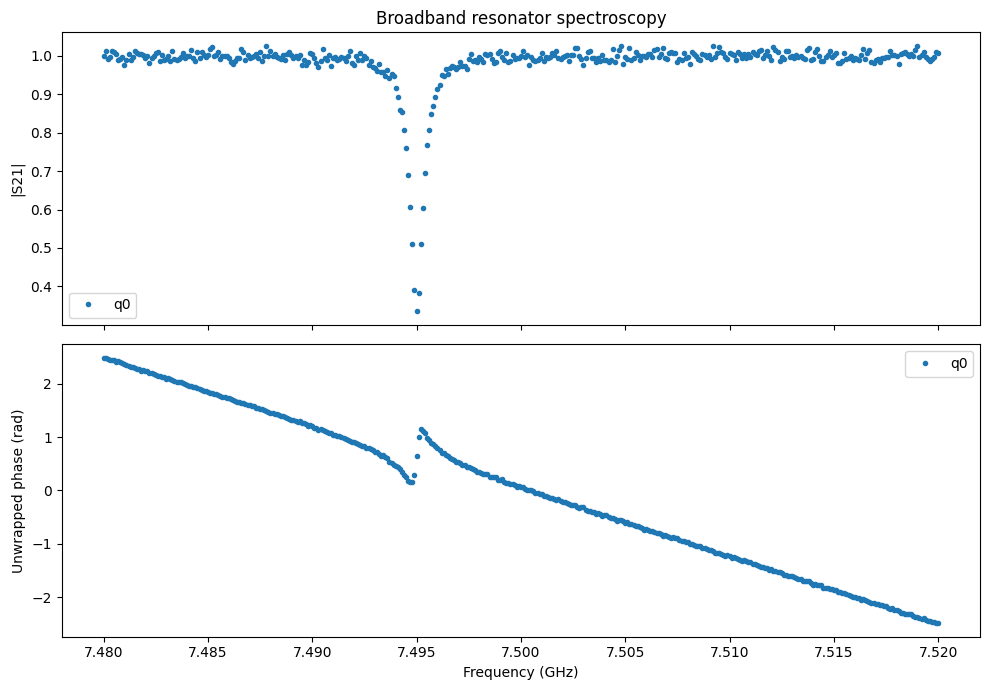

In [8]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [9]:
if SAVE_DETECTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_DETECTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json
